### Simulação do Cenário 1 

In [1]:
import random
from quantumnet.components import Network, Host, Controller
from quantumnet.components import ServerNode, ClientNode, RegularNode
from quantumnet.objects import Qubit, Logger

Hosts inicializados
Canais inicializados
Pares EPRs adicionados


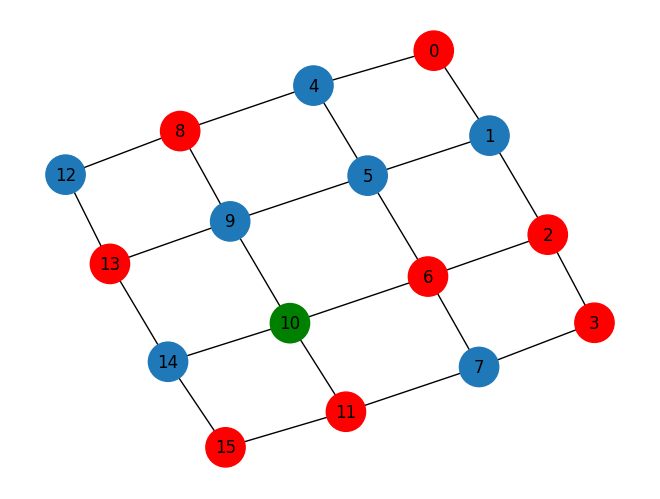

In [2]:
rede = Network()
controller = Controller(rede)
rede.set_ready_topology('grade', 8, 4, 4, clients=[13,8,2,6,0,3,11,15], server=10)  
rede.draw()


##### Nessa parte, eu posso gerar minha requesições, dos protocolos Childs(AC_BQC) e BFK_BQC.

##### O cenário 1 apresenta o agendamento das requesições de forma que pode-se executar protocolos em caminhos diferentes, porém no mesmo timeslot.

In [3]:
clientes = [13,8,2,6,0,3,11,15]

for _ in range(5):  # Escolha de quantas requisições serão feitas
    alice_id = random.choice(clientes)
    bob_id = 10
    num_qubits = 5
    num_gates = 20
    scenario = 1

    # Gere a requisição sem 'slice_path'
    request = rede.generate_request(
        alice_id=alice_id,
        bob_id=bob_id,
        num_qubits=num_qubits,
        num_gates=num_gates,
        scenario=scenario
    )
    controller.receive_request(request)

controller.process_requests()
controller.send_scheduled_requests()




                ┌───┐┌───┐┌───┐┌───┐          ┌───┐
q_0: ────■──────┤ X ├┤ Z ├┤ H ├┤ T ├──────────┤ X ├
         │ ┌───┐└─┬─┘└───┘├───┤├───┤          └─┬─┘
q_1: ─■──┼─┤ Z ├──┼────■──┤ H ├┤ Y ├────────────┼──
      │  │ └───┘  │  ┌─┴─┐└───┘├───┤┌───┐┌───┐  │  
q_2: ─■──■────────┼──┤ X ├──■──┤ X ├┤ Y ├┤ X ├──■──
                  │  ├───┤  │  ├───┤├───┤└─┬─┘     
q_3: ─■───────────┼──┤ X ├──┼──┤ X ├┤ T ├──┼───────
      │           │  └─┬─┘  │  └─┬─┘└───┘  │  ┌───┐
q_4: ─■───────────■────■────■────■─────────■──┤ T ├
                                              └───┘
                       ┌───┐          ┌───┐┌───┐
q_0: ──────────■───────┤ X ├───────■──┤ Y ├┤ Y ├
     ┌───┐     │       └─┬─┘┌───┐  │  ├───┤├───┤
q_1: ┤ T ├─────┼────X────┼──┤ Z ├──■──┤ Y ├┤ H ├
     └───┘     │    │    │  ├───┤┌───┐├───┤└───┘
q_2: ──■───────┼────┼────■──┤ S ├┤ T ├┤ X ├─────
       │       │    │  ┌───┐└───┘└───┘└───┘     
q_3: ──┼───■───┼────X──┤ H ├──■─────────────────
       │   │ ┌─┴─┐┌───┐└───┘  │  ┌──

##### Nesse parte, pode-se gerar requesições de somente um protocolo.

In [4]:
clientes = [13,8,2,6,0,3,11,15]

for _ in range(5):
    alice_id = random.choice(clientes)
    bob_id = 0  
    num_qubits = 5
    num_gates = 20 
    scenario = 1  

    
    request = rede.generate_request(
        alice_id=alice_id,
        bob_id=bob_id,
        num_qubits=num_qubits,
        num_gates=num_gates,
        scenario=scenario
    )
    
    request['protocol'] = "AC_BQC"  # Define o protocolo a ser usado: "BFK_BQC" ou "AC_BQC"

    # Envia a requisição para o controlador
    controller.receive_request(request)

# Processa e executa as requisições
controller.process_requests()
controller.send_scheduled_requests()


     ┌───┐        ┌───┐                     ┌───┐┌───┐
q_0: ┤ Y ├──────■─┤ H ├──────────────■───■──┤ S ├┤ T ├
     ├───┤┌───┐ │ ├───┤              │   │  └───┘└───┘
q_1: ┤ X ├┤ H ├─┼─┤ T ├─────■────────┼───┼────────────
     └───┘├───┤ │ └───┘     │        │   │            
q_2: ─────┤ X ├─┼───────────┼────────┼───┼────■───────
     ┌───┐└─┬─┘ │ ┌───┐     │        │   │    │  ┌───┐
q_3: ┤ Z ├──┼───■─┤ S ├─■───┼────────┼───■────┼──┤ X ├
     ├───┤  │     └───┘ │ ┌─┴─┐┌───┐ │ ┌───┐┌─┴─┐└─┬─┘
q_4: ┤ H ├──■───────────■─┤ X ├┤ Y ├─■─┤ S ├┤ X ├──■──
     └───┘                └───┘└───┘   └───┘└───┘     
                                       ┌───┐                       
q_0: ──■────■──────────────────────────┤ X ├───────■───X───────────
       │    │  ┌───┐                   └─┬─┘       │   │           
q_1: ──┼────■──┤ Y ├─────────────────────┼─────────┼───┼───────────
     ┌─┴─┐┌───┐├───┤           ┌───┐     │         │   │      ┌───┐
q_2: ┤ X ├┤ T ├┤ Y ├─X───────X─┤ Y ├─────┼─────────┼───

##### Mostra o relatório de execução das requesições.

In [5]:
controller.generate_schedule_report()

=== Relatório de Requisições ===

Requisições Executadas:
- Alice ID: 11, Bob ID: 10, Nº de Qubits: 5, Circuit Depth: 10, Timeslot: 3

Requisições que falharam:
- Alice ID: 6, Bob ID: 10, Nº de Qubits: 5, Circuit Depth: 9, Rota: None, Motivo: Falha desconhecida
- Alice ID: 0, Bob ID: 10, Nº de Qubits: 5, Circuit Depth: 7, Rota: None, Motivo: Falha desconhecida
- Alice ID: 15, Bob ID: 10, Nº de Qubits: 5, Circuit Depth: 10, Rota: None, Motivo: Falha desconhecida
- Alice ID: 13, Bob ID: 10, Nº de Qubits: 5, Circuit Depth: 10, Rota: None, Motivo: Falha desconhecida
- Alice ID: 15, Bob ID: 0, Nº de Qubits: 5, Circuit Depth: 10, Rota: None, Motivo: Falha desconhecida
- Alice ID: 8, Bob ID: 0, Nº de Qubits: 5, Circuit Depth: 12, Rota: None, Motivo: Falha desconhecida
- Alice ID: 15, Bob ID: 0, Nº de Qubits: 5, Circuit Depth: 11, Rota: None, Motivo: Falha desconhecida
- Alice ID: 2, Bob ID: 0, Nº de Qubits: 5, Circuit Depth: 11, Rota: None, Motivo: Falha desconhecida
- Alice ID: 0, Bob ID: 0,

{'success': 1,
 'failed': 9,
 'scheduled': 0,
 'failed_details': [{'alice_id': 6,
   'bob_id': 10,
   'num_qubits': 5,
   'circuit_depth': 9,
   'route': None,
   'reason': 'Falha desconhecida'},
  {'alice_id': 0,
   'bob_id': 10,
   'num_qubits': 5,
   'circuit_depth': 7,
   'route': None,
   'reason': 'Falha desconhecida'},
  {'alice_id': 15,
   'bob_id': 10,
   'num_qubits': 5,
   'circuit_depth': 10,
   'route': None,
   'reason': 'Falha desconhecida'},
  {'alice_id': 13,
   'bob_id': 10,
   'num_qubits': 5,
   'circuit_depth': 10,
   'route': None,
   'reason': 'Falha desconhecida'},
  {'alice_id': 15,
   'bob_id': 0,
   'num_qubits': 5,
   'circuit_depth': 10,
   'route': None,
   'reason': 'Falha desconhecida'},
  {'alice_id': 8,
   'bob_id': 0,
   'num_qubits': 5,
   'circuit_depth': 12,
   'route': None,
   'reason': 'Falha desconhecida'},
  {'alice_id': 15,
   'bob_id': 0,
   'num_qubits': 5,
   'circuit_depth': 11,
   'route': None,
   'reason': 'Falha desconhecida'},
  {'al

##### Contabiliza quantos EPRs foram usados.

In [6]:
rede.get_total_useds_eprs()

150

##### Mostra a fidelidade das rotas utilizadas.

In [7]:
rede.application_layer.avg_fidelity_on_applicationlayer()

0.7174139770533771

In [8]:
rede.application_layer.print_route_fidelities()

Fidelidades das rotas utilizadas:
0.8595
0.8424
0.7491
0.6441
0.8228
0.7257
0.7413
0.6192
0.5134
0.7721
0.7429
0.5765
